In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import os,sys
from clawpack.amrclaw import region_tools
from clawpack.geoclaw import topotools, dtopotools, kmltools, fgmax_tools, marching_front
from clawpack.visclaw import colormaps
from IPython.display import Image

In [2]:
topo_fname = 'etopo10min120W60W60S0S_smoothed.tt2'
topo = topotools.Topography(os.path.join(".",topo_fname), topo_type=2)

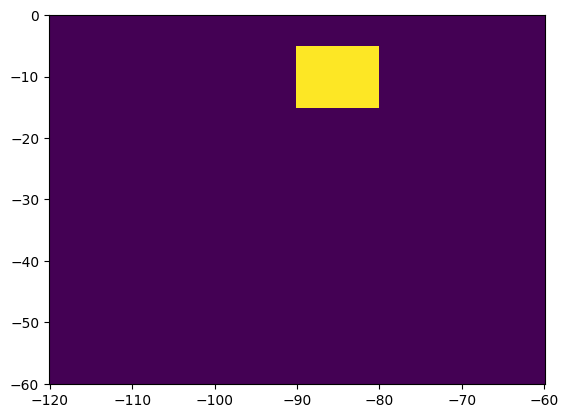

In [4]:
maskx = np.where(np.logical_and(topo.X>-90,topo.X<-80),1,0)
masky = np.where(np.logical_and(topo.Y>-15,topo.Y<-5),1,0)
mask = maskx*masky
plt.pcolormesh(topo.X,topo.Y,mask)


In [5]:
#Create ruled rectangle
rr = region_tools.ruledrectangle_covering_selected_points(topo.X, topo.Y,
                                                          mask, ixy='y', method=0,
                                                          verbose=True)

Extending rectangles to cover grid cells
RuledRectangle covers 3660 grid points


<Figure size 640x480 with 0 Axes>

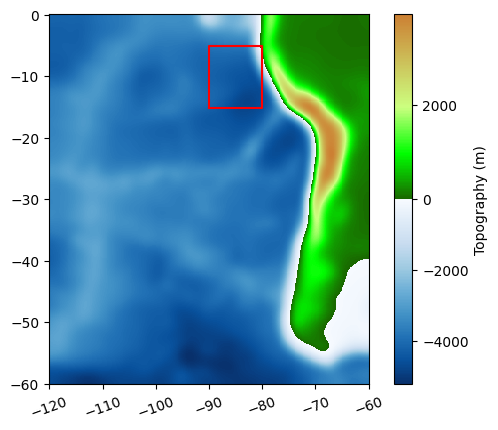

In [6]:
plt.figure()
x1,y1 = rr.vertices()
topo.plot()
plt.plot(x1,y1,'r')


In [7]:
rr.write(fname='flag2refine_rrs/rr1.data')